In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

class PlainBlock(nn.Module):
    # Standard Block
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(channels, channels),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Linear(channels,channels),
            nn.BatchNorm1d(channels)
        )
    
    def forward(self, x):
        return F.relu(self.net(x))
    
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(channels, channels),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Linear(channels, channels),
            nn.BatchNorm1d(channels)
        )
    
    def forward(self, x):
        return F.relu(self.net(x) + x)          # The only difference between classic and residual
    
class PlainNetwork (nn.Module):
    def __init__(self, input_dim, hidden, num_blocks, num_classes):
        super().__init__()
        self.input_proj = nn.Linear(input_dim,hidden)
        self.blocks = nn.Sequential(
            *[PlainBlock(hidden) for _ in range(num_blocks)]
        )
        self.classifier = nn.Linear(hidden, num_classes)
    
    def forward(self, x):
        x = F.relu(self.input_proj(x))
        x = self.blocks(x)
        return self.classifier(x)

class ResNet(nn.Module):
    def __init__(self, input_dim, hidden, num_blocks, num_classes):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden)
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden) for _ in range(num_blocks)]
        )
        self.classifier = nn.Linear(hidden, num_classes)
    
    def forward(self, x):
        x = F.relu(self.input_proj(x))
        x = self.blocks(x)
        return self.classifier(x)

x_test   = torch.randn(8, 32)
plain_b  = PlainBlock(32)
resid_b  = ResidualBlock(32)
print(f"PlainBlock output:    {plain_b(x_test).shape}")
print(f"ResidualBlock output: {resid_b(x_test).shape}")




Using device: mps
PlainBlock output:    torch.Size([8, 32])
ResidualBlock output: torch.Size([8, 32])


In [8]:
def measure_gradient_flow(model, x, y, criterion):
    """
    Forward + backward pass, measure gradient magnitude
    at each layer. Shows how well gradients reach early layers.
    """
    model.zero_grad()
    out  = model(x)
    loss = criterion(out, y)
    loss.backward()

    grad_norms = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            grad_norms.append((name, param.grad.norm().item()))

    return grad_norms


torch.manual_seed(42)
N          = 200
X_dummy    = torch.randn(N, 32).to(device)
y_dummy    = torch.randint(0, 4, (N,)).to(device)
criterion  = nn.CrossEntropyLoss()

NUM_BLOCKS = 10   # deep enough to see vanishing gradient effect

plain_net  = PlainNetwork(32, 64, NUM_BLOCKS, 4).to(device)
resnet     = ResNet(32, 64, NUM_BLOCKS, 4).to(device)

plain_grads = measure_gradient_flow(plain_net, X_dummy, y_dummy, criterion)
resnet_grads = measure_gradient_flow(resnet,   X_dummy, y_dummy, criterion)

print(f"\n── Gradient Norms (early → late layers) ───────────")
print(f"{'Layer':<45} {'Plain':>10} {'ResNet':>10}")
print("─" * 65)
for (pname, pnorm), (rname, rnorm) in zip(plain_grads, resnet_grads):
    short = pname[:44]
    print(f"{short:<45} {pnorm:>10.6f} {rnorm:>10.6f}")


── Gradient Norms (early → late layers) ───────────
Layer                                              Plain     ResNet
─────────────────────────────────────────────────────────────────
input_proj.weight                              10.281944   4.159575
blocks.0.net.0.weight                          12.186183   4.665593
blocks.0.net.1.weight                           0.628172   0.278999
blocks.0.net.3.weight                          10.394858   3.907771
blocks.0.net.4.weight                           0.651448   0.251226
blocks.1.net.0.weight                           8.534876   3.118024
blocks.1.net.1.weight                           0.533734   0.159570
blocks.1.net.3.weight                           6.870110   2.569008
blocks.1.net.4.weight                           0.403077   0.178989
blocks.2.net.0.weight                           5.307896   2.265791
blocks.2.net.1.weight                           0.298621   0.114787
blocks.2.net.3.weight                           4.634094   1.9177

In [11]:
torch.manual_seed(0)
N    = 1000
X    = torch.randn(N, 32)
# Multi-class task
y    = (X[:, :4].argmax(dim=1))

split   = int(0.8 * N)
X_tr    = X[:split].to(device)
y_tr    = y[:split].to(device)
X_vl    = X[split:].to(device)
y_vl    = y[split:].to(device)

def train_model(model, epochs=50, lr=0.01, batch_size=64):
    optimizer    = optim.Adam(model.parameters(), lr=lr)
    criterion    = nn.CrossEntropyLoss()
    train_losses = []
    val_accs     = []

    for epoch in range(epochs):
        model.train()
        perm       = torch.randperm(X_tr.shape[0])
        epoch_loss = 0
        n_batches  = 0

        for i in range(0, X_tr.shape[0], batch_size):
            idx    = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            preds   = model(X_vl).argmax(dim=1)
            val_acc = (preds == y_vl).float().mean().item()
        val_accs.append(val_acc)

    return train_losses, val_accs

print("\nTraining Plain Network (50 blocks)...")
plain_model  = PlainNetwork(32, 64, 50, 4).to(device)
plain_losses, plain_accs = train_model(plain_model, epochs=50)

print("Training ResNet (50 blocks)...")
resnet_model = ResNet(32, 64, 50, 4).to(device)
resnet_losses, resnet_accs = train_model(resnet_model, epochs=50)

print(f"\nFinal Val Accuracy:")
print(f"  Plain:  {plain_accs[-1]:.3f}")
print(f"  ResNet: {resnet_accs[-1]:.3f}")


Training Plain Network (50 blocks)...
Training ResNet (50 blocks)...

Final Val Accuracy:
  Plain:  0.230
  ResNet: 0.800


10 blocks, gradient diagnostic:
  Plain gradient ratio: 26x  ← already unstable, just not bad enough yet
  ResNet gradient ratio: ~1x ← perfectly stable

10 blocks, accuracy:
  Plain:  84.5%   ← task easy enough, both work
  ResNet: 82.0%

50 blocks, accuracy:
  Plain:  23.0%   ← collapsed completely
  ResNet: 80.0%   ← still works fine

In [12]:
class ConvResidualBlock(nn.Module):
    """
    Standard ResNet block for images.
    Two 3x3 convolutions with a skip connection.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Projection shortcut — needed when dimensions change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)   # skip connection
        return F.relu(out)

# Shape test with images
x_img = torch.randn(2, 16, 32, 32)    # (batch, channels, H, W)

# Same channels, same spatial size — identity shortcut
block_same = ConvResidualBlock(16, 16)
print(f"\nConv ResBlock (same dims):    "
      f"{x_img.shape} → {block_same(x_img).shape}")

# Different channels — projection shortcut kicks in
block_proj = ConvResidualBlock(16, 32, stride=2)
print(f"Conv ResBlock (proj shortcut): "
      f"{x_img.shape} → {block_proj(x_img).shape}")


Conv ResBlock (same dims):    torch.Size([2, 16, 32, 32]) → torch.Size([2, 16, 32, 32])
Conv ResBlock (proj shortcut): torch.Size([2, 16, 32, 32]) → torch.Size([2, 32, 16, 16])


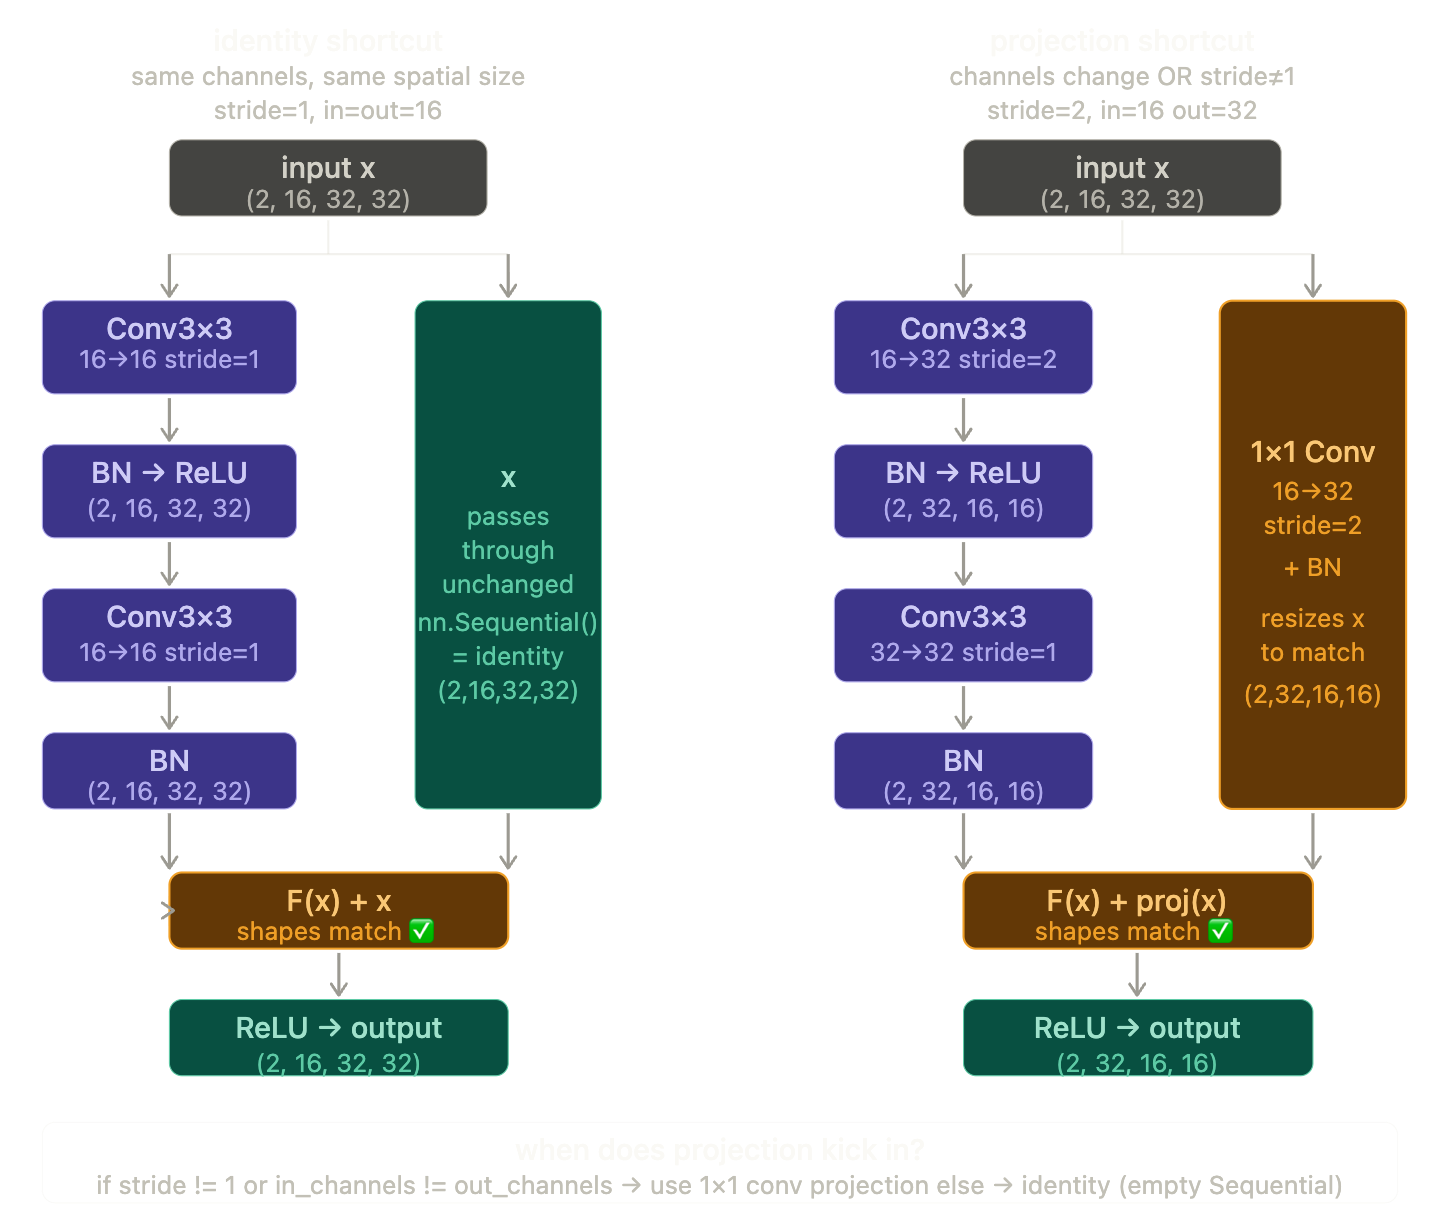

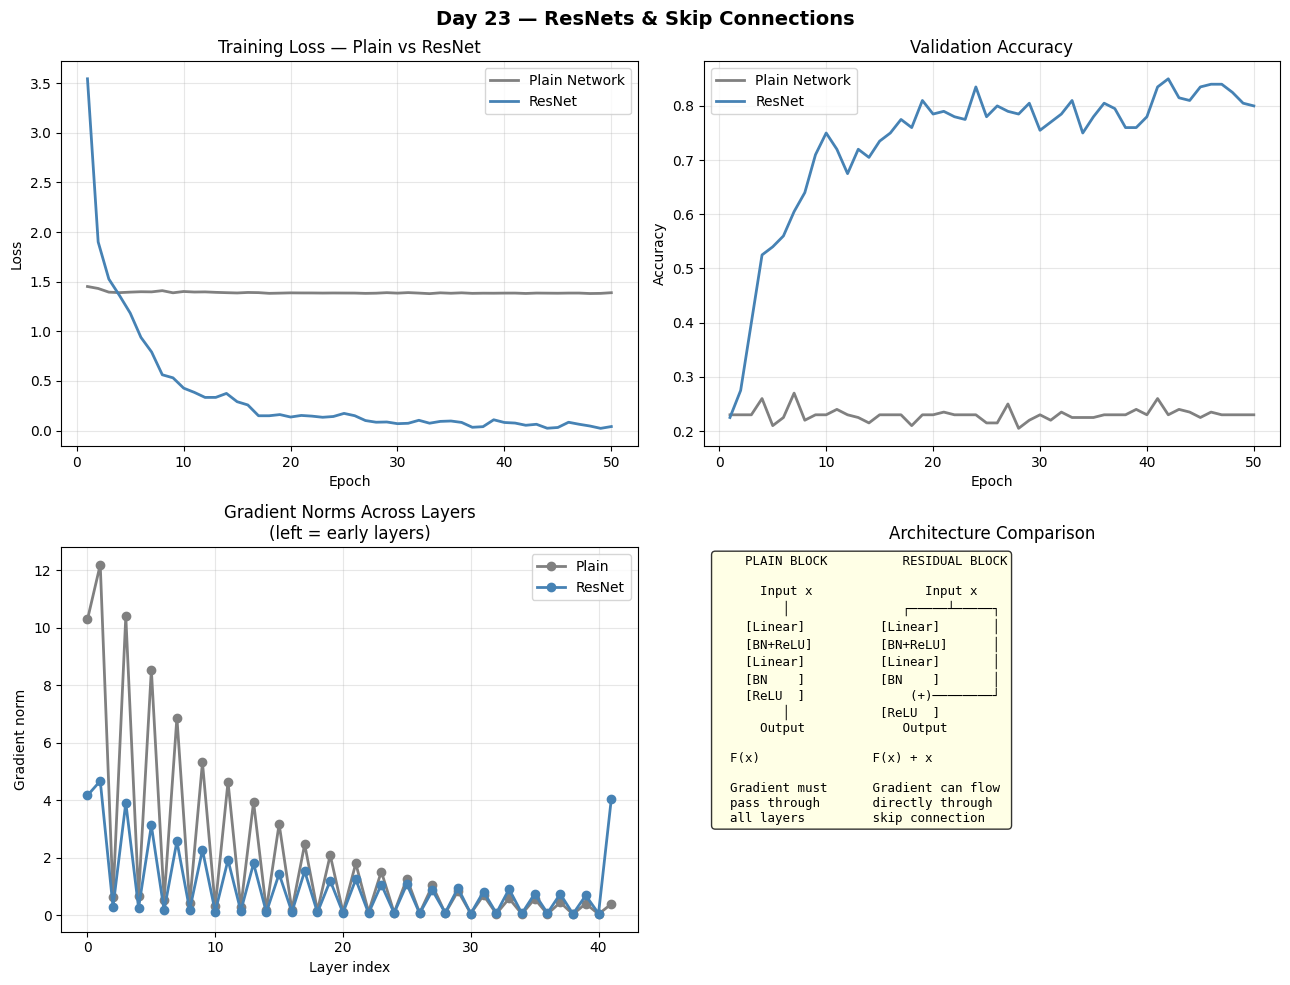

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Day 23 — ResNets & Skip Connections',
             fontsize=14, fontweight='bold')

epochs_r = range(1, 51)

# Training loss
axes[0, 0].plot(epochs_r, plain_losses,
                label='Plain Network', color='gray',      linewidth=2)
axes[0, 0].plot(epochs_r, resnet_losses,
                label='ResNet',        color='steelblue', linewidth=2)
axes[0, 0].set_title('Training Loss — Plain vs ResNet')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation accuracy
axes[0, 1].plot(epochs_r, plain_accs,
                label='Plain Network', color='gray',      linewidth=2)
axes[0, 1].plot(epochs_r, resnet_accs,
                label='ResNet',        color='steelblue', linewidth=2)
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gradient flow comparison
layer_indices = range(len(plain_grads))
plain_norms   = [g[1] for g in plain_grads]
resnet_norms  = [g[1] for g in resnet_grads]
axes[1, 0].plot(layer_indices, plain_norms,
                label='Plain', color='gray',      linewidth=2, marker='o')
axes[1, 0].plot(layer_indices, resnet_norms,
                label='ResNet', color='steelblue', linewidth=2, marker='o')
axes[1, 0].set_title('Gradient Norms Across Layers\n(left = early layers)')
axes[1, 0].set_xlabel('Layer index')
axes[1, 0].set_ylabel('Gradient norm')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Residual block diagram
axes[1, 1].axis('off')
diagram = (
    "    PLAIN BLOCK          RESIDUAL BLOCK\n\n"
    "      Input x               Input x\n"
    "         │               ┌─────┴─────┐\n"
    "    [Linear]          [Linear]       │\n"
    "    [BN+ReLU]         [BN+ReLU]      │\n"
    "    [Linear]          [Linear]       │\n"
    "    [BN    ]          [BN    ]       │\n"
    "    [ReLU  ]              (+)────────┘\n"
    "         │            [ReLU  ]\n"
    "      Output             Output\n\n"
    "  F(x)               F(x) + x\n\n"
    "  Gradient must      Gradient can flow\n"
    "  pass through       directly through\n"
    "  all layers         skip connection"
)
axes[1, 1].text(0.02, 0.98, diagram, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 1].set_title('Architecture Comparison')

plt.tight_layout()
plt.show()